In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
df = pd.read_csv("Online Retail.csv")
print(df.columns.tolist())
print(df.head())

['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

        InvoiceDate  UnitPrice  CustomerID         Country  
0  01-12-2010 08:26       2.55     17850.0  United Kingdom  
1  01-12-2010 08:26       3.39     17850.0  United Kingdom  
2  01-12-2010 08:26       2.75     17850.0  United Kingdom  
3  01-12-2010 08:26       3.39     17850.0  United Kingdom  
4  01-12-2010 08:26       3.39     17850.0  United Kingdom  


In [4]:
import pandas as pd

# If df is already loaded, keep it and normalize the headers
df.columns = df.columns.astype(str).str.strip()

required = {
    "InvoiceNo",
    "InvoiceDate",
    "Quantity",
    "UnitPrice",
}

print("Columns found:", df.columns.tolist())

missing_cols = required - set(df.columns)

if missing_cols:
    raise ValueError(
        f"Unexpected dataset schema; missing columns: {sorted(missing_cols)}"
    )

# Convert columns to the correct data types
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["UnitPrice"] = pd.to_numeric(df["UnitPrice"], errors="coerce")

# Calculate line sales value
df["SalesGBP"] = df["Quantity"] * df["UnitPrice"]

print("\nDataset validation successful!")
print("Rows:", len(df))
print("Columns:", df.columns.tolist())
print("Date range:", df["InvoiceDate"].min(), "to", df["InvoiceDate"].max())

display(df.head())

Columns found: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Dataset validation successful!
Rows: 541909
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'SalesGBP']
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,SalesGBP
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [5]:
# Checking the data quality before forecasting

# Check data quality
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDate range:")
print(df["InvoiceDate"].min(), "to", df["InvoiceDate"].max())

print("\nQuantity summary:")
print(df["Quantity"].describe())

print("\nUnit price summary:")
print(df["UnitPrice"].describe())

print("\nCancellation invoices:", 
      df["InvoiceNo"].astype(str).str.startswith("C").sum())

Dataset shape: (541909, 9)

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
SalesGBP            0
dtype: int64

Duplicate rows: 5268

Date range:
2010-12-01 08:26:00 to 2011-12-09 12:50:00

Quantity summary:
count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

Unit price summary:
count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

Cancellation invoices: 9288


In [8]:
# Data cleaning for sales analysis

import pandas as pd
import numpy as np

# Keep the original dataset unchanged
sales_df = df.copy()

# Remove exact duplicate rows
sales_df = sales_df.drop_duplicates().copy()

# Standardize column data types
sales_df["InvoiceNo"] = sales_df["InvoiceNo"].astype(str).str.strip()
sales_df["InvoiceDate"] = pd.to_datetime(
    sales_df["InvoiceDate"], errors="coerce"
)
sales_df["Quantity"] = pd.to_numeric(
    sales_df["Quantity"], errors="coerce"
)
sales_df["UnitPrice"] = pd.to_numeric(
    sales_df["UnitPrice"], errors="coerce"
)

# Identify cancellation rows
sales_df["IsCancellation"] = (
    sales_df["InvoiceNo"].str.startswith("C")
)

# Exclude cancellations and non-positive quantities/prices
sales_df = sales_df[
    (~sales_df["IsCancellation"])
    & (sales_df["Quantity"] > 0)
    & (sales_df["UnitPrice"] > 0)
    & (sales_df["InvoiceDate"].notna())
].copy()

# Calculate positive invoice-line value
sales_df["SalesGBP"] = (
    sales_df["Quantity"] * sales_df["UnitPrice"]
)

print("Original rows:", len(df))
print("Rows after cleaning:", len(sales_df))
print("Rows removed:", len(df) - len(sales_df))
print("Remaining missing values:")
print(sales_df.isnull().sum())
print("\nCleaned sales value (£):", round(sales_df["SalesGBP"].sum(), 2))

Original rows: 541909
Rows after cleaning: 524878
Rows removed: 17031
Remaining missing values:
InvoiceNo              0
StockCode              0
Description            0
Quantity               0
InvoiceDate            0
UnitPrice              0
CustomerID        132186
Country                0
SalesGBP               0
IsCancellation         0
dtype: int64

Cleaned sales value (£): 10642110.8


Monthly sales (£):
InvoiceDate
2010-12-01     821452.73
2011-01-01     689811.61
2011-02-01     522545.56
2011-03-01     716215.26
2011-04-01     536968.49
2011-05-01     769296.61
2011-06-01     760547.01
2011-07-01     718076.12
2011-08-01     757841.38
2011-09-01    1056435.19
2011-10-01    1151263.73
2011-11-01    1503866.78
2011-12-01     637790.33
Freq: MS, Name: SalesGBP, dtype: float64


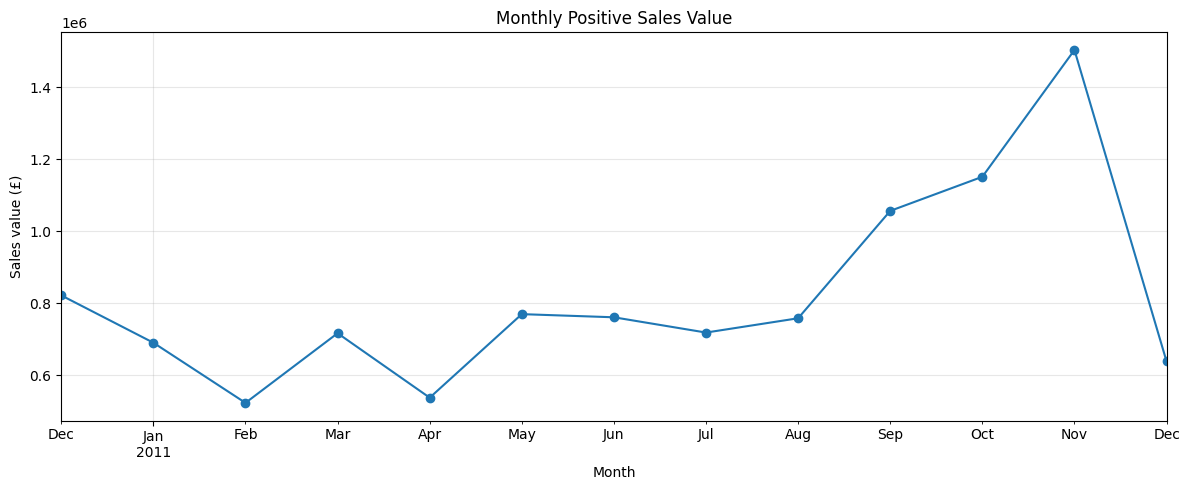

In [9]:
# Visualize the monthly sales trend

import matplotlib.pyplot as plt

monthly_sales = (
    sales_df.set_index("InvoiceDate")["SalesGBP"]
    .resample("MS")
    .sum()
)

print("Monthly sales (£):")
print(monthly_sales.round(2))

plt.figure(figsize=(12, 5))
monthly_sales.plot(marker="o")
plt.title("Monthly Positive Sales Value")
plt.xlabel("Month")
plt.ylabel("Sales value (£)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("monthly_sales_trend.png", dpi=300)
plt.show()

MONTHLY SALES (£)
InvoiceDate
2010-12-01     821452.73
2011-01-01     689811.61
2011-02-01     522545.56
2011-03-01     716215.26
2011-04-01     536968.49
2011-05-01     769296.61
2011-06-01     760547.01
2011-07-01     718076.12
2011-08-01     757841.38
2011-09-01    1056435.19
2011-10-01    1151263.73
2011-11-01    1503866.78
2011-12-01     637790.33
Freq: MS, Name: SalesGBP, dtype: float64


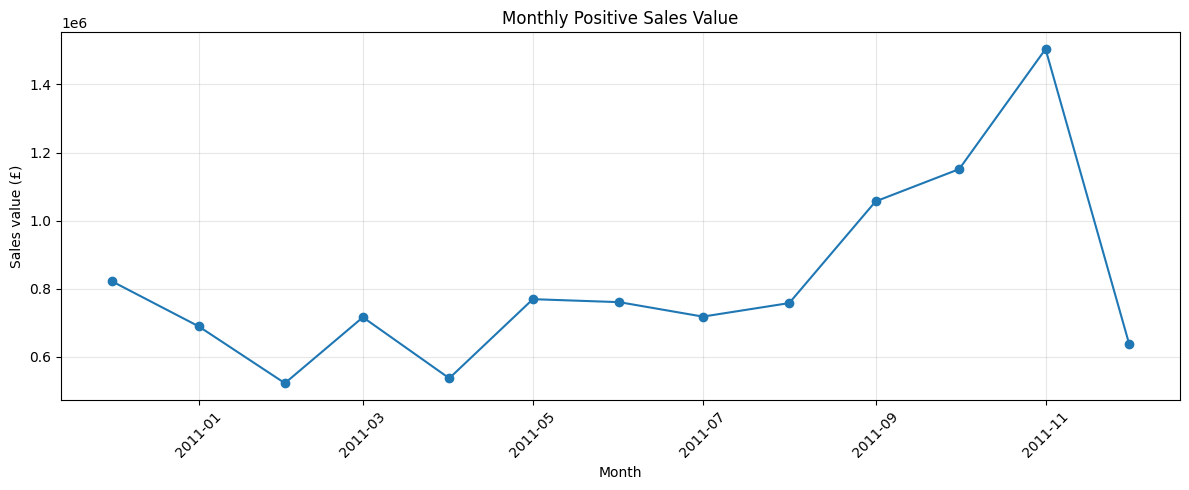


TOP 10 COUNTRIES BY SALES (£)
Country
United Kingdom    9001744.09
Netherlands        285446.34
EIRE               283140.52
Germany            228678.40
France             209625.37
Australia          138453.81
Spain               61558.56
Switzerland         57067.60
Belgium             41196.34
Sweden              38367.83
Name: SalesGBP, dtype: float64


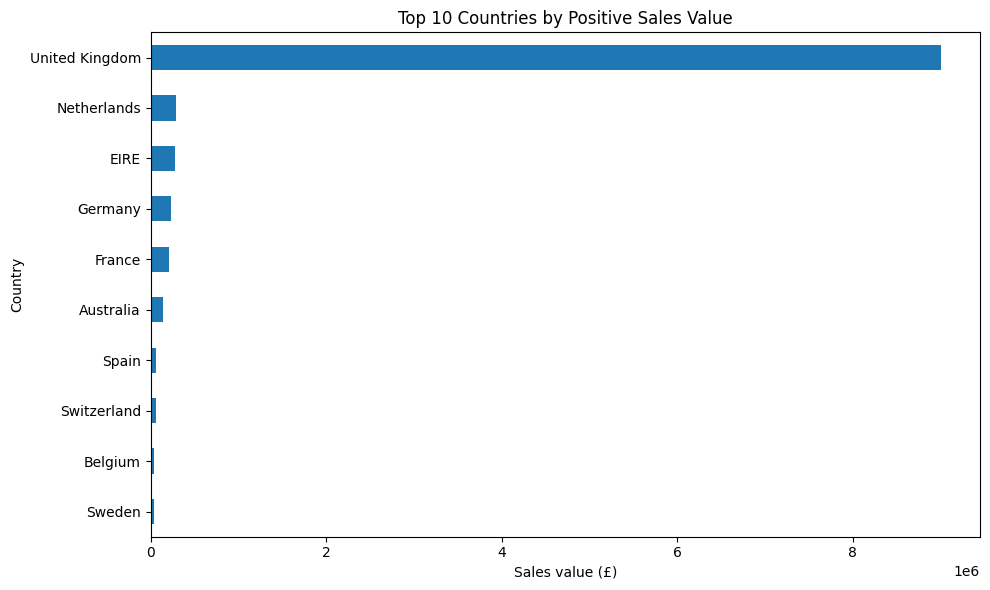


TOP 10 PRODUCTS BY SALES (£)
Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78101.88
Manual                                 77752.82
RABBIT NIGHT LIGHT                     66870.03
Name: SalesGBP, dtype: float64


In [10]:
#Visualize monthly sales and identify top markets


import matplotlib.pyplot as plt

# 1. Aggregate positive sales value by month
monthly_sales = (
    sales_df.set_index("InvoiceDate")["SalesGBP"]
    .resample("MS")
    .sum()
)

print("MONTHLY SALES (£)")
print(monthly_sales.round(2))

# 2. Plot the monthly trend
plt.figure(figsize=(12, 5))
plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)
plt.title("Monthly Positive Sales Value")
plt.xlabel("Month")
plt.ylabel("Sales value (£)")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Top 10 countries by positive sales value
country_sales = (
    sales_df.groupby("Country")["SalesGBP"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTOP 10 COUNTRIES BY SALES (£)")
print(country_sales.round(2))

plt.figure(figsize=(10, 6))
country_sales.sort_values().plot(kind="barh")
plt.title("Top 10 Countries by Positive Sales Value")
plt.xlabel("Sales value (£)")
plt.tight_layout()
plt.savefig("top_10_countries_sales.png", dpi=300)
plt.show()

# 4. Top 10 products by positive invoice-line value
product_sales = (
    sales_df.groupby("Description")["SalesGBP"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTOP 10 PRODUCTS BY SALES (£)")
print(product_sales.round(2))

In [11]:
# Improve the product analysis,seperate postage and other non standard description from ordinary merchandise products. This will help in better understanding of the product sales and trends.


# Inspect the highest-value descriptions
product_sales_all = (
    sales_df.groupby("Description")["SalesGBP"]
    .sum()
    .sort_values(ascending=False)
)

print("Top 20 descriptions:")
print(product_sales_all.head(20).round(2))

# Exclude obvious service/administrative descriptions
non_merchandise = [
    "DOTCOM POSTAGE",
    "POSTAGE",
    "Manual"
]

merchandise_df = sales_df[
    ~sales_df["Description"].isin(non_merchandise)
].copy()

top_merchandise = (
    merchandise_df.groupby("Description")["SalesGBP"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTOP 10 MERCHANDISE DESCRIPTIONS (£):")
print(top_merchandise.round(2))

Top 20 descriptions:
Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78101.88
Manual                                 77752.82
RABBIT NIGHT LIGHT                     66870.03
PAPER CHAIN KIT 50'S CHRISTMAS         64875.59
ASSORTED COLOUR BIRD ORNAMENT          58927.62
CHILLI LIGHTS                          54096.36
SPOTTY BUNTING                         42513.48
JUMBO BAG PINK POLKADOT                42401.01
BLACK RECORD COVER FRAME               40633.38
PICNIC BASKET WICKER 60 PIECES         39619.50
DOORMAT KEEP CALM AND COME IN          38133.64
SET OF 3 CAKE TINS PANTRY DESIGN       38108.89
JAM MAKING SET WITH JARS               37082.13
Name: S

Number of weeks: 54

Weekly sales summary:
count        54.00
mean     197076.13
std       87191.48
min           0.00
25%      139622.88
50%      179714.77
75%      218723.62
max      503767.75
Name: SalesGBP, dtype: float64

Last 10 weeks:
InvoiceDate
2011-10-09    319084.77
2011-10-16    228037.07
2011-10-23    275970.35
2011-10-30    259312.53
2011-11-06    300643.08
2011-11-13    368996.32
2011-11-20    387064.65
2011-11-27    315114.06
2011-12-04    323398.70
2011-12-11    503767.75
Freq: W-SUN, Name: SalesGBP, dtype: float64


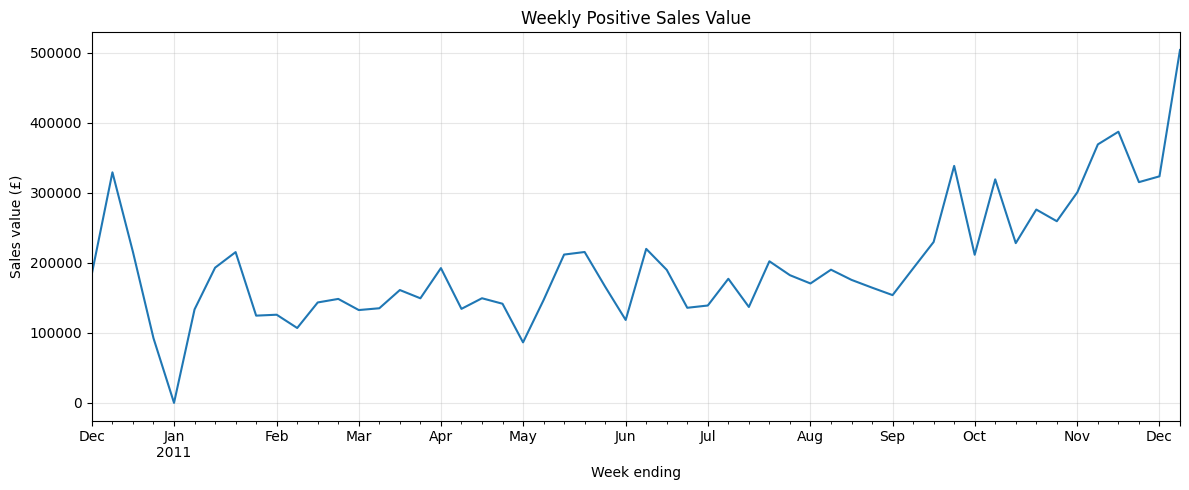

In [12]:
# Forecasting model 
# Creating the weekly sales use to train and evaluate the forecasting model.


import pandas as pd
import matplotlib.pyplot as plt

# Aggregate cleaned sales into weekly totals (Monday-start weeks)
weekly_sales = (
    sales_df.set_index("InvoiceDate")["SalesGBP"]
    .resample("W-SUN")
    .sum()
)

# Use consistent week-ending Sunday labels
weekly_sales.index = weekly_sales.index.to_period("W-SUN").end_time.normalize()

# Fill any missing weeks with zero sales
weekly_sales = weekly_sales.asfreq("W-SUN", fill_value=0)

print("Number of weeks:", len(weekly_sales))
print("\nWeekly sales summary:")
print(weekly_sales.describe().round(2))

print("\nLast 10 weeks:")
print(weekly_sales.tail(10).round(2))

# Plot weekly sales
plt.figure(figsize=(12, 5))
weekly_sales.plot()
plt.title("Weekly Positive Sales Value")
plt.xlabel("Week ending")
plt.ylabel("Sales value (£)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("weekly_sales_trend.png", dpi=300)
plt.show()

Complete-week observations: 52
Modeling period: 2010-12-12 00:00:00 to 2011-12-04 00:00:00

MODEL COMPARISON
                Model  MAE (£)  RMSE (£)  WAPE (%)
4-week moving average 37668.91  51997.37     12.26
       Naive baseline 45453.27  53405.45     14.79
        Random Forest 53100.16  65466.99     17.28


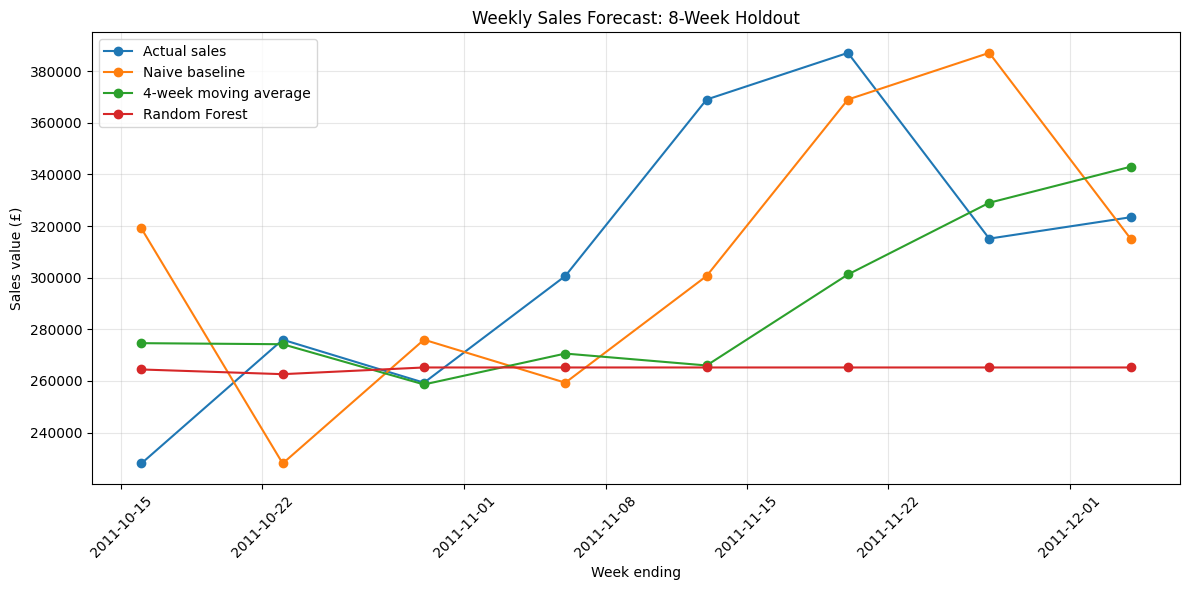

In [14]:
# Comapare the three forecasting models


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Rebuild weekly sales with Sunday week-ending labels
weekly_sales = (
    sales_df.set_index("InvoiceDate")["SalesGBP"]
    .resample("W-SUN")
    .sum()
    .sort_index()
)

# Exclude the first and last partial weeks
weekly_sales = weekly_sales.iloc[1:-1].copy()

print("Complete-week observations:", len(weekly_sales))
print("Modeling period:", weekly_sales.index.min(), "to",
      weekly_sales.index.max())

# 2. Create features using only current and past information
data = pd.DataFrame({"Sales": weekly_sales})
data["lag1"] = data["Sales"].shift(1)
data["lag2"] = data["Sales"].shift(2)
data["lag3"] = data["Sales"].shift(3)
data["lag4"] = data["Sales"].shift(4)

# Shift before rolling to prevent target leakage
data["rolling_mean_4"] = data["Sales"].shift(1).rolling(4).mean()
data["week_number"] = data.index.isocalendar().week.astype(int)
data["month"] = data.index.month

data = data.dropna()

features = [
    "lag1", "lag2", "lag3", "lag4",
    "rolling_mean_4", "week_number", "month"
]

# 3. Chronological holdout: last 8 usable weeks
holdout_size = 8
train = data.iloc[:-holdout_size].copy()
test = data.iloc[-holdout_size:].copy()

X_train = train[features]
y_train = train["Sales"]
X_test = test[features]
y_test = test["Sales"]

# 4. Naive and moving-average forecasts
predictions = {
    "Naive baseline": test["lag1"].to_numpy(),
    "4-week moving average": test["rolling_mean_4"].to_numpy()
}

# 5. Random Forest
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=2,
    random_state=42
)

rf.fit(X_train, y_train)
predictions["Random Forest"] = rf.predict(X_test)

# 6. Evaluate every model on the same holdout weeks
results = []

for name, pred in predictions.items():
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    wape = (
        np.abs(y_test.to_numpy() - pred).sum()
        / np.abs(y_test.to_numpy()).sum()
        * 100
    )

    results.append({
        "Model": name,
        "MAE (£)": round(mae, 2),
        "RMSE (£)": round(rmse, 2),
        "WAPE (%)": round(wape, 2)
    })

results_df = pd.DataFrame(results).sort_values("WAPE (%)")

print("\nMODEL COMPARISON")
print(results_df.to_string(index=False))

# 7. Plot actual versus predicted sales
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, marker="o",
         label="Actual sales")

for name, pred in predictions.items():
    plt.plot(y_test.index, pred, marker="o", label=name)

plt.title("Weekly Sales Forecast: 8-Week Holdout")
plt.xlabel("Week ending")
plt.ylabel("Sales value (£)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("weekly_sales_forecast_comparison.png", dpi=300)
plt.show()

FOUR-WEEK SALES FORECAST
WeekEnding ForecastSalesGBP
2011-12-11      £348,643.43
2011-12-18      £343,555.21
2011-12-25      £332,677.85
2012-01-01      £337,068.80


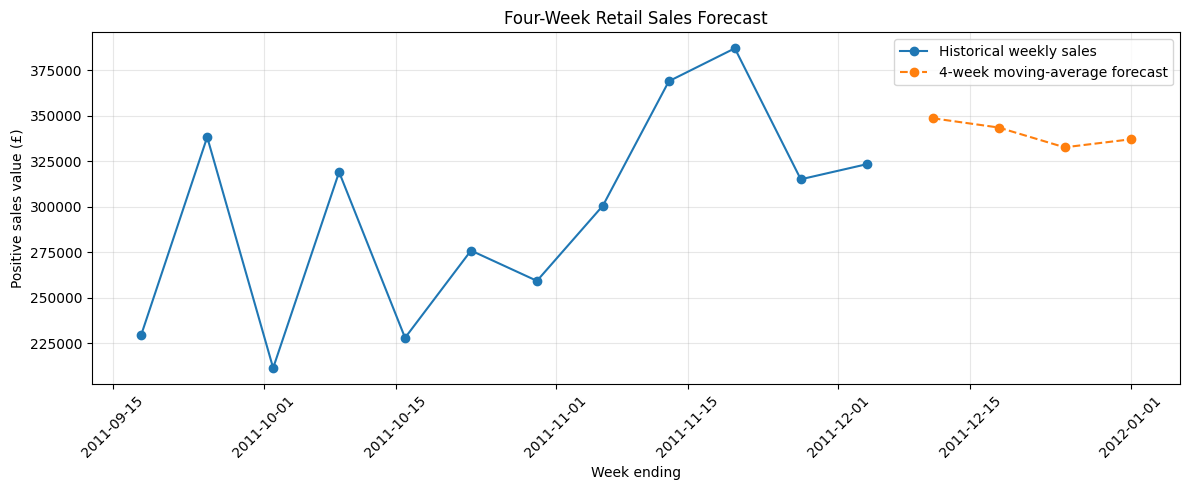


Saved: next_4_week_forecast.csv


In [16]:
# Generating the next 4 weeks of sales forecasts


import pandas as pd
import matplotlib.pyplot as plt

# Rebuild weekly sales consistently
weekly_all = (
    sales_df.set_index("InvoiceDate")["SalesGBP"]
    .resample("W-SUN")
    .sum()
    .sort_index()
)

# Remove partial boundary weeks
complete_weeks = weekly_all.iloc[1:-1].copy()

# Forecast four weeks recursively
history = complete_weeks.tolist()
last_complete_date = complete_weeks.index[-1]

forecast_values = []

for _ in range(4):
    prediction = sum(history[-4:]) / 4
    forecast_values.append(prediction)
    history.append(prediction)

forecast_dates = pd.date_range(
    start=last_complete_date + pd.Timedelta(days=7),
    periods=4,
    freq="W-SUN"
)

forecast_df = pd.DataFrame({
    "WeekEnding": forecast_dates,
    "ForecastSalesGBP": forecast_values
})

print("FOUR-WEEK SALES FORECAST")
print(forecast_df.to_string(
    index=False,
    formatters={"ForecastSalesGBP": "£{:,.2f}".format}
))

# Plot recent actuals and forecast
plt.figure(figsize=(12, 5))
plt.plot(
    complete_weeks.index[-12:],
    complete_weeks.values[-12:],
    marker="o",
    label="Historical weekly sales"
)
plt.plot(
    forecast_df["WeekEnding"],
    forecast_df["ForecastSalesGBP"],
    marker="o",
    linestyle="--",
    label="4-week moving-average forecast"
)

plt.title("Four-Week Retail Sales Forecast")
plt.xlabel("Week ending")
plt.ylabel("Positive sales value (£)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("next_4_week_forecast.png", dpi=300)
plt.show()

# Save forecast for your report
forecast_df.to_csv("next_4_week_forecast.csv", index=False)
print("\nSaved: next_4_week_forecast.csv")